# Zadanie 1: optymalizacja gradientowa

Wybraliśmy funkcję **Himmelblaua**:
$$
F(x_1, x_2) = (x_1^2 + x_2 - 11)^2 + (x_1 + x_2^2 - 7)^2.
$$

Jest to klasyczna funkcja testowa w optymalizacji numerycznej. 
Jest nieliniowa, ma kilka minimów lokalnych/globalnych i dzięki temu dobrze pokazuje wpływ:
- punktu startowego,
- doboru kroku,
- sposobu przeszukiwania liniowego.

Dziedzina przeszukiwania: `[-5, 5] × [-5, 5]`.


In [ ]:
using LinearAlgebra
using Plots
using Random
using Statistics

In [3]:
lower = [-5.0, -5.0]
upper = [ 5.0,  5.0]

known_minima = [
    [ 3.0,  2.0],
    [-2.805118,  3.131312],
    [-3.779310, -3.283186],
    [ 3.584428, -1.848126],
]

4-element Vector{Vector{Float64}}:
 [3.0, 2.0]
 [-2.805118, 3.131312]
 [-3.77931, -3.283186]
 [3.584428, -1.848126]

## Definicja funkcji i gradientu

In [4]:
Random.seed!(2026)

function himmelblau(x::AbstractVector)
    x1, x2 = x
    return (x1^2 + x2 - 11)^2 + (x1 + x2^2 - 7)^2
end

function grad_himmelblau!(g, x)
    x1, x2 = x
    g[1] = 4x1 * (x1^2 + x2 - 11) + 2 * (x1 + x2^2 - 7)
    g[2] = 2 * (x1^2 + x2 - 11) + 4x2 * (x1 + x2^2 - 7)
    return g
end

grad_himmelblau! (generic function with 1 method)

### Jak został policzony gradient?

Aby zastosować metodę gradientową, potrzebujemy gradientu funkcji.

Niech
$$
A(x_1,x_2)=x_1^2+x_2-11, \qquad B(x_1,x_2)=x_1+x_2^2-7.
$$

Wtedy funkcję można zapisać jako
$$
F(x_1,x_2)=A(x_1,x_2)^2 + B(x_1,x_2)^2.
$$

Korzystając z reguły łańcuchowej:
$$
\frac{\partial F}{\partial x_1}
=
2A\frac{\partial A}{\partial x_1}
+
2B\frac{\partial B}{\partial x_1}.
$$

Ponieważ
$$
\frac{\partial A}{\partial x_1}=2x_1, \qquad \frac{\partial B}{\partial x_1}=1,
$$
otrzymujemy
$$
\frac{\partial F}{\partial x_1}
=
4x_1(x_1^2+x_2-11)+2(x_1+x_2^2-7).
$$

Analogicznie:
$$
\frac{\partial F}{\partial x_2}
=
2A\frac{\partial A}{\partial x_2}
+
2B\frac{\partial B}{\partial x_2}.
$$

Ponieważ
$$
\frac{\partial A}{\partial x_2}=1, \qquad \frac{\partial B}{\partial x_2}=2x_2,
$$
dostajemy
$$
\frac{\partial F}{\partial x_2}
=
2(x_1^2+x_2-11)+4x_2(x_1+x_2^2-7).
$$

Zatem gradient ma postać
$$
\nabla F(x_1,x_2)=
\begin{bmatrix}
4x_1(x_1^2+x_2-11)+2(x_1+x_2^2-7) \\
2(x_1^2+x_2-11)+4x_2(x_1+x_2^2-7)
\end{bmatrix}.
$$

## Wybranie punktów startowych

In [5]:
function random_point(lower, upper)
    return lower .+ rand(length(lower)) .* (upper .- lower)
end

starts = [random_point(lower, upper) for _ in 1:10]

println("Wylosowane punkty startowe:")
for (i, s) in enumerate(starts)
    println("x0[$i] = ", round.(s, digits=4))
end


Wylosowane punkty startowe:
x0[1] = [1.1309, -2.014]
x0[2] = [0.4691, 0.9928]
x0[3] = [-3.7056, -1.8503]
x0[4] = [1.8495, 3.9898]
x0[5] = [-1.1216, 3.5968]
x0[6] = [-2.1657, 3.7558]
x0[7] = [2.054, -4.5357]
x0[8] = [4.2303, -3.5243]
x0[9] = [-2.7792, -2.4919]
x0[10] = [0.772, 3.3115]


## Funkcja optymalizująca - gradient descent

In [6]:
function gradient_descent(f, grad!, x0; alpha=1e-2, maxiter=100, tol=1e-8)
    x = copy(x0)
    g = similar(x)
    values = Float64[]
    gradnorms = Float64[]
    traj = Vector{Vector{Float64}}()

    grad!(g, x)
    push!(values, f(x))
    push!(gradnorms, norm(g))
    push!(traj, copy(x))

    for _ in 1:maxiter
        grad!(g, x)
        
        x .-= alpha .* g
        grad!(g, x)
        push!(values, f(x))
        push!(gradnorms, norm(g))
        push!(traj, copy(x))
    end

    return x, values, gradnorms, traj
end

gradient_descent (generic function with 1 method)

## Część na 3.0 — stały krok

Poniżej porównujemy kilka wartości kroku `α`.
Chcemy pokazać trzy typowe sytuacje:
- **brak zbieżności** — krok za duży,
- **szybka zbieżność** — krok dobrze dobrany,
- **powolna zbieżność** — krok za mały.


Dla każdej wartości kroku wykonujemy 10 uruchomień z losowych punktów startowych, 
a następnie analizuję zarówno średni przebieg wartości funkcji, jak i pojedyncze trajektorie.


In [12]:
alphas = [0.001, 0.005, 0.01, 0.02, 0.05]
results_fixed = Dict{Float64, Vector{Vector{Float64}}}()

# dla wykresu wyników
results_for_plots = Dict{Float64, Vector{Float64}}()

for alpha in alphas
    histories = Vector{Vector{Float64}}()
    results = Vector{Float64}()
    
    for x0 in starts
        x_current, values, gradnorms, traj = gradient_descent(himmelblau, grad_himmelblau!, x0; alpha=alpha, maxiter=100)
        push!(histories, values)
        push!(results, himmelblau(x_current))
    end

    results_fixed[alpha] = histories
    results_for_plots[alpha] = results
end


In [13]:
fixed_summary = Dict{Float64, NamedTuple}()
for alpha in alphas
    finals = results_for_plots[alpha]
    fixed_summary[alpha] = (
        mean_final = mean(finals),
        median_final = median(finals),
        min_final = minimum(finals),
        max_final = maximum(finals),
    )
end

fixed_summary

Dict{Float64, NamedTuple} with 5 entries:
  0.01  => (mean_final = 3.12e-25, median_final = 5.1276e-30, min_final = 7.888…
  0.005 => (mean_final = 1.80531e-11, median_final = 9.33625e-14, min_final = 1…
  0.02  => (mean_final = 9.22069, median_final = 7.09975e-30, min_final = 0.0, …
  0.001 => (mean_final = 0.105876, median_final = 0.0116481, min_final = 3.7108…
  0.05  => (mean_final = NaN, median_final = NaN, min_final = NaN, max_final = …

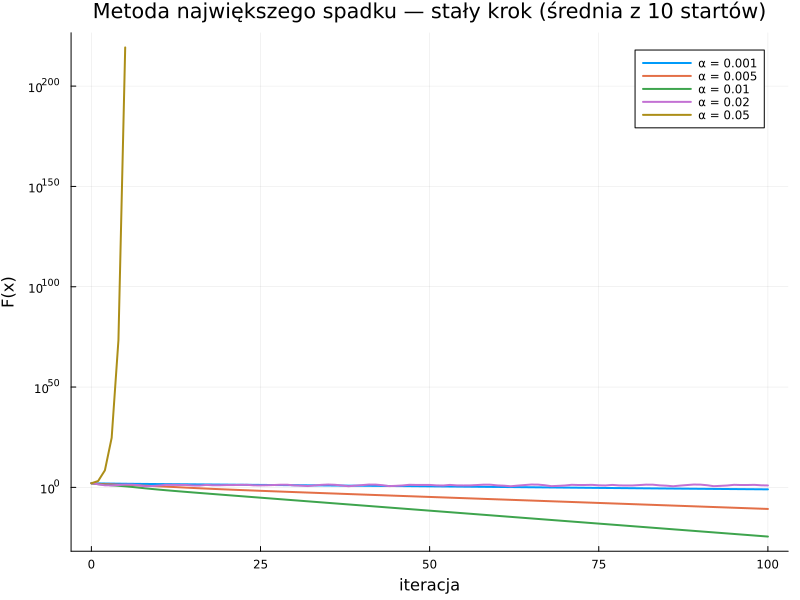

In [14]:
plot(
    title="Metoda największego spadku — stały krok (średnia z 10 startów)",
    xlabel="iteracja",
    ylabel="F(x)",
    yscale=:log10,
    legend=:topright,
    size=(800, 600)
)
for α in alphas
    mean_history = mean(reduce(hcat, results_fixed[α]), dims=2)[:]
    plot!(0:100, mean_history; label="α = $(α)", lw=2)
end
current()


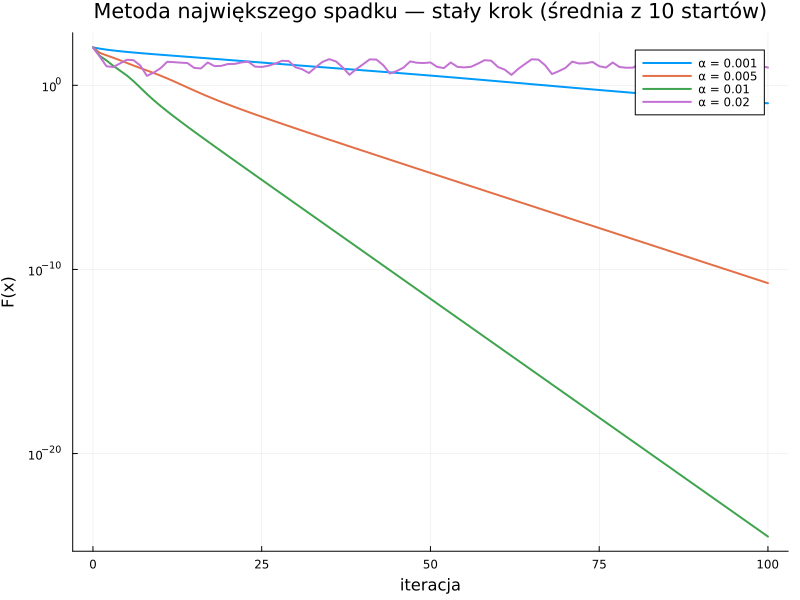

In [11]:
alphas_subset = [0.001, 0.005, 0.01, 0.02]

plot(
    title="Metoda największego spadku — stały krok (średnia z 10 startów)",
    xlabel="iteracja",
    ylabel="F(x)",
    yscale=:log10,
    legend=:topright,
    size=(800, 600)
)
for alpha in alphas_subset
    mean_history = mean(reduce(hcat, results_fixed[alpha]), dims=2)[:]
    plot!(0:100, mean_history; label="α = $(alpha)", lw=2)
end
current()


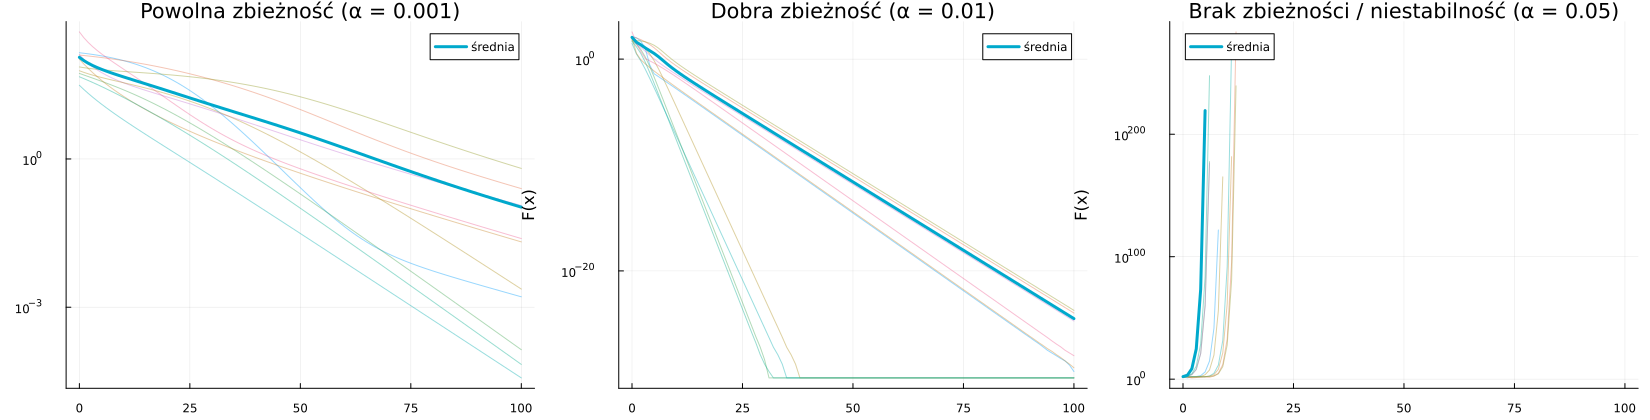

In [15]:
alpha_slow = 0.001
alpha_good = 0.01
alpha_bad  = 0.05

p1 = plot(title="Powolna zbieżność (α = $(alpha_slow))", xlabel="iteracja", ylabel="F(x)", yscale=:log10)
for values in results_fixed[alpha_slow]
    plot!(p1, 0:length(values)-1, values; lw=1, alpha=0.4, label=false)
end
mean_values = mean(reduce(hcat, results_fixed[alpha_slow]), dims=2)[:]
plot!(p1, 0:length(mean_values)-1, mean_values; lw=3, label="średnia")

p2 = plot(title="Dobra zbieżność (α = $(alpha_good))", xlabel="iteracja", ylabel="F(x)", yscale=:log10)
for values in results_fixed[alpha_good]
    plot!(p2, 0:length(values)-1, values; lw=1, alpha=0.4, label=false)
end
mean_values = mean(reduce(hcat, results_fixed[alpha_good]), dims=2)[:]
plot!(p2, 0:length(mean_values)-1, mean_values; lw=3, label="średnia")

p3 = plot(title="Brak zbieżności / niestabilność (α = $(alpha_bad))", xlabel="iteracja", ylabel="F(x)", yscale=:log10)
for values in results_fixed[alpha_bad]
    plot!(p3, 0:length(values)-1, values; lw=1, alpha=0.4, label=false)
end
mean_values = mean(reduce(hcat, results_fixed[alpha_bad]), dims=2)[:]
plot!(p3, 0:length(mean_values)-1, mean_values; lw=3, label="średnia")

plot(p1, p2, p3; layout=(1,3), size=(1650,420))

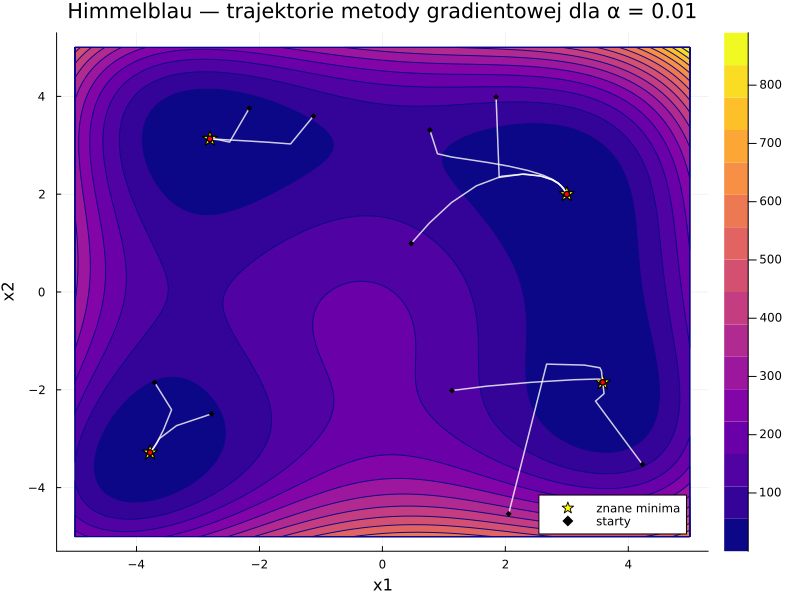

In [16]:
# siatka do konturu
xs = range(lower[1], upper[1], length=250)
ys = range(lower[2], upper[2], length=250)
zs = [himmelblau([x, y]) for y in ys, x in xs]   # albo Twoja funkcja f([x,y])

p = contourf(xs, ys, zs; fill=true, color=:plasma,
             xlabel="x1", ylabel="x2", title="Himmelblau — trajektorie metody gradientowej dla α = 0.01")

scatter!(p, [m[1] for m in known_minima], [m[2] for m in known_minima];
    color=:yellow, marker=:star5, ms=8, label="znane minima")

# narysuj trajektorie i punkty końcowe z obliczeń
for x0 in starts
    x_end, _, gradnorms, traj = gradient_descent(himmelblau, grad_himmelblau!, x0; alpha=0.01, maxiter=100)

    tx = [pt[1] for pt in traj]
    ty = [pt[2] for pt in traj]
    plot!(p, tx, ty; lw=1.5, color=:white, alpha=0.8, label=false, size=(800, 600))
    scatter!(p, [x_end[1]], [x_end[2]]; color=:red, ms=3, label=false)
end

# starty
scatter!(p, [s[1] for s in starts], [s[2] for s in starts];
         color=:black, ms=3, marker=:diamond, label="starty")

display(p)


### Interpretacja części 3.0

- Dla małego kroku algorytm porusza się bezpiecznie, ale wolno.
- Dla kroku średniej wielkości funkcja szybko maleje.
- Dla zbyt dużego kroku metoda potrafi „przeskakiwać” przez dolinę i traci stabilność.

To jest bardzo typowe w optymalizacji gradientowej — sam gradient nie wystarcza, trzeba jeszcze dobrze wybrać długość kroku.

Dodatkowo, ponieważ funkcja Himmelblaua ma kilka minimów, różne punkty startowe mogą prowadzić do różnych minimów końcowych nawet przy tym samym kroku.


## Część na 4.0 — warunek Armijo

Zamiast ręcznie ustawiać stały krok, możemy dobierać go adaptacyjnie.

W każdej iteracji bierzemy kierunek największego spadku:
$$
d_k = -\nabla F(x_k),
$$
a następnie szukamy takiego kroku $\alpha$, aby spełniony był warunek Armijo:
$$
F(x_k + \alpha d_k) \leq F(x_k) + c_1 \alpha \nabla F(x_k)^T d_k.
$$

Ponieważ
$$
d_k = -\nabla F(x_k),
$$
to iloczyn
$$
\nabla F(x_k)^T d_k = -\|\nabla F(x_k)\|^2 < 0,
$$
więc prawa strona jest mniejsza od $F(x_k)$. Oznacza to, że akceptujemy tylko taki krok, który daje wystarczający spadek funkcji.

W tej części przyjmujemy początkowy zakres przeszukiwania odpowiadający krokowi startowemu $\alpha_0 = 1$ i jego kolejnemu zmniejszaniu.

Przyjmujemy początkowy bracket \([0,1]\) zgodnie z poleceniem:
- górna granica przedziału to \(\alpha_0 = 1.0\),
- dolna granica to \(0\),
- backtracking Armijo testuje kolejne kroki: \(1, \beta, \beta^2, \dots\), czyli kroki należące do \([0,1]\).

W ten sposób przeszukiwanie liniowe w części 4.0 startuje od bracketu \([0,1]\).


In [17]:
function armijo_backtracking(f, x, g, d; alpha0=1.0, beta=0.5, c1=1e-4, alpha_min=1e-12)
    alpha = alpha0
    fx = f(x)
    gd = dot(g, d)

    while alpha >= alpha_min
        if f(x .+ alpha .* d) <= fx + c1 * alpha * gd
            return alpha
        end
        alpha *= beta
    end

    return alpha_min
end

function gradient_descent_armijo(f, grad!, x0; alpha0=1.0, beta=0.5, c1=1e-4, maxiter=100, tol=1e-8)
    x = copy(x0)
    g = similar(x)
    values = Float64[]
    gradnorms = Float64[]
    alphas = Float64[]
    traj = Vector{Vector{Float64}}()

    grad!(g, x)
    push!(values, f(x))
    push!(gradnorms, norm(g))
    push!(traj, copy(x))

    for _ in 1:maxiter
        grad!(g, x)
        # if norm(g) < tol
        #     break
        # end
        d = -copy(g)
        alpha = armijo_backtracking(f, x, g, d; alpha0=alpha0, beta=beta, c1=c1)
        x .+= alpha .* d

        grad!(g, x)
        push!(values, f(x))
        push!(gradnorms, norm(g))
        push!(alphas, alpha)
        push!(traj, copy(x))
    end
    return x, values, gradnorms, alphas, traj
end


gradient_descent_armijo (generic function with 1 method)

In [18]:
armijo_params = [
    (β=0.1, c1=1e-4),
    (β=0.3, c1=1e-4),
    (β=0.5, c1=1e-4),
    (β=0.5, c1=1e-3),
    (β=0.7, c1=1e-4),
    (β=0.7, c1=1e-2),
]

armijo_fixed_results = Dict{Tuple{Float64,Float64}, Vector{Vector{Float64}}}()
for pars in armijo_params
    histories = Vector{Vector{Float64}}()
    for x0 in starts
        x, values, gradnorms, alphas, traj = gradient_descent_armijo(himmelblau, grad_himmelblau!, x0; alpha0=1.0, beta=pars.β, c1=pars.c1, maxiter=100)
        push!(histories, values)
    end
    armijo_fixed_results[(pars.β, pars.c1)] = histories
end


In [19]:
armijo_summary = Dict{Tuple{Float64,Float64}, NamedTuple}()

for pars in armijo_params
    key = (pars.β, pars.c1)
    finals = [hist[end] for hist in armijo_fixed_results[key]]
    armijo_summary[key] = (
        mean_final = mean(finals),
        median_final = median(finals),
        min_final = minimum(finals),
        max_final = maximum(finals),
    )
end

armijo_summary

Dict{Tuple{Float64, Float64}, NamedTuple} with 6 entries:
  (0.7, 0.01)   => (mean_final = 1.76721e-14, median_final = 3.9443e-31, min_fi…
  (0.1, 0.0001) => (mean_final = 1.24195e-25, median_final = 5.1276e-30, min_fi…
  (0.5, 0.001)  => (mean_final = 3.9443e-31, median_final = 3.9443e-31, min_fin…
  (0.7, 0.0001) => (mean_final = 3.10589e-14, median_final = 7.88861e-31, min_f…
  (0.3, 0.0001) => (mean_final = 5.52203e-31, median_final = 0.0, min_final = 0…
  (0.5, 0.0001) => (mean_final = 3.9443e-31, median_final = 3.9443e-31, min_fin…

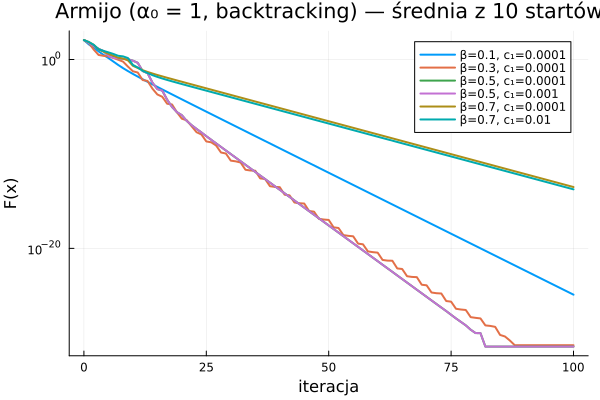

In [20]:
plot(title="Armijo (α₀ = 1, backtracking) — średnia z 10 startów", xlabel="iteracja", ylabel="F(x)", yscale=:log10)
for pars in armijo_params
    key = (pars.β, pars.c1)
    mean_history = mean(reduce(hcat, armijo_fixed_results[key]), dims=2)[:]
    plot!(0:100, mean_history; label="β=$(pars.β), c₁=$(pars.c1)", lw=2)
end
current()


### Jak rozumieć parametry Armijo?

- `c1` mówi, jak duży spadek uznajemy za wystarczający.
  Mniejsze `c1` zwykle łatwiej zaakceptować.
- `β` mówi, jak mocno zmniejszamy próbny krok, gdy warunek nie jest spełniony.
  Na przykład `β = 0.5` oznacza: testujemy `1`, potem `0.5`, potem `0.25`, itd.


Duże `β` (np. `0.7`) oznacza łagodniejsze zmniejszanie kroku, a małe `β` (np. `0.1`) — bardzo agresywne skracanie.


## Część na 5.0 — automatyczne wyznaczanie bracketingu

W tej części zastępujemy stały bracket `[0,1]` metodą z wykładu `bracket_minimum`.

Dla funkcji jednowymiarowej
$$
\phi(\alpha)=F(x_k+\alpha d_k),\quad d_k=-\nabla F(x_k),
$$
wyznaczamy automatycznie przedział \([a,b]\) przez rozszerzanie kroku:
$$
0,\ s,\ s\cdot k,\ s\cdot k^2,\dots
$$
aż do spełnienia warunku bracketingu (zgodnie z implementacją `bracket_minimum`).

Następnie wykonujemy backtracking Armijo wewnątrz znalezionego przedziału (start od `a_hi=b`).

W porównaniu 1:1 z metodą z 4.0 utrzymujemy te same parametry Armijo (`beta`, `c1`) i zmieniamy tylko parametry bracketingu (`s`, `k`, `n`).


In [ ]:
# 1) Bracketing z wykładu 
function bracket_minimum(f, x=0.0; s=1e-2, k=2.0, n=20)
    a, ya = x, f(x)
    b, yb = a + s, f(a + s)

    if yb > ya
        a, b = b, a
        ya, yb = yb, ya
        s = -s
    end

    for _ in 1:n
        c, yc = b + s, f(b + s)
        if yc > yb
            return a < c ? (a, c) : (c, a)
        end
        a, ya, b, yb = b, yb, c, yc
        s *= k
    end
    return (NaN, NaN)
end


bracket_minimum (generic function with 2 methods)

In [22]:
# 2) Armijo na zadanym bracketcie + auto-bracketing z wykładu
function armijo_on_bracket(f, x, g, d; a_lo=0.0, a_hi=1.0, beta=0.5, c1=1e-4, alpha_min=1e-12)
    fx = f(x)
    gd = dot(g, d)                     # < 0 dla d = -g
    alpha = a_hi

    while alpha >= max(a_lo, alpha_min)
        if f(x .+ alpha .* d) <= fx + c1 * alpha * gd
            return alpha
        end
        alpha *= beta
    end
    return max(a_lo, alpha_min)
end

function armijo_backtracking_auto_lecture(f, x, g, d; s=1e-3, k=2.0, n=20, beta=0.5, c1=1e-4)
    phi(α) = f(x .+ α .* d)
    a, b = bracket_minimum(phi, 0.0; s=s, k=k, n=n)
    if isnan(a) || isnan(b)
        a, b = 0.0, 1.0   # fallback
    end
    return armijo_on_bracket(f, x, g, d; a_lo=a, a_hi=b, beta=beta, c1=c1)
end


armijo_backtracking_auto_lecture (generic function with 1 method)

In [23]:
# 3) GD z auto-bracketingiem + porównanie z baseline [0,1]
function gradient_descent_armijo_auto_lecture(f, grad!, x0; s=1e-3, k=2.0, n=20, beta=0.5, c1=1e-4, maxiter=100)
    x = copy(x0)
    g = similar(x)
    values = Float64[]
    push!(values, f(x))

    for _ in 1:maxiter
        grad!(g, x)
        d = -copy(g)
        α = armijo_backtracking_auto_lecture(f, x, g, d; s=s, k=k, n=n, beta=beta, c1=c1)
        x .+= α .* d
        push!(values, f(x))
    end
    return x, values
end

# baseline [0,1] (do porównania 1:1)
function gradient_descent_armijo_fixed_bracket(f, grad!, x0; beta=0.5, c1=1e-4, maxiter=100)
    x = copy(x0)
    g = similar(x)
    values = Float64[]
    push!(values, f(x))

    for _ in 1:maxiter
        grad!(g, x)
        d = -copy(g)
        α = armijo_on_bracket(f, x, g, d; a_lo=0.0, a_hi=1.0, beta=beta, c1=c1)
        x .+= α .* d
        push!(values, f(x))
    end
    return x, values
end


gradient_descent_armijo_fixed_bracket (generic function with 1 method)

In [24]:
# import Pkg;

# Pkg.add("DataFrames")

In [25]:
using Statistics, DataFrames

beta = 0.5
c1 = 1e-4
maxiter = 100

bracket_params = [
    (s=1e-4, k=1.5, n=20),
    (s=1e-4, k=2.0, n=20),
    (s=1e-3, k=1.5, n=20),
    (s=1e-3, k=2.0, n=20),
    (s=1e-3, k=3.0, n=20),
    (s=1e-2, k=2.0, n=30),
]

# baseline [0,1]
fixed_histories = Vector{Vector{Float64}}()
for x0 in starts
    _, vals = gradient_descent_armijo_fixed_bracket(himmelblau, grad_himmelblau!, x0;
        beta=beta, c1=c1, maxiter=maxiter)
    push!(fixed_histories, vals)
end

rows = DataFrame(method=String[], s=Float64[], k=Float64[], n=Int[],
                 mean_final=Float64[], median_final=Float64[], min_final=Float64[], max_final=Float64[])

fixed_finals = [h[end] for h in fixed_histories]
push!(rows, ("Armijo [0,1]", NaN, NaN, 0,
    mean(fixed_finals), median(fixed_finals), minimum(fixed_finals), maximum(fixed_finals)))

auto_histories_dict = Dict{NTuple{3,Float64}, Vector{Vector{Float64}}}()

for p in bracket_params
    histories = Vector{Vector{Float64}}()
    for x0 in starts
        _, vals = gradient_descent_armijo_auto_lecture(himmelblau, grad_himmelblau!, x0;
            s=p.s, k=p.k, n=p.n, beta=beta, c1=c1, maxiter=maxiter)
        push!(histories, vals)
    end
    finals = [h[end] for h in histories]
    push!(rows, ("Armijo + auto bracket", p.s, p.k, p.n,
        mean(finals), median(finals), minimum(finals), maximum(finals)))
    auto_histories_dict[(p.s, p.k, Float64(p.n))] = histories
end

sort!(rows, :mean_final)
rows


Row,method,s,k,n,mean_final,median_final,min_final,max_final
,String,Float64,Float64,Int64,Float64,Float64,Float64,Float64
1,Armijo + auto bracket,0.0001,1.5,20,3.15544e-31,0.0,0.0,7.88861e-31
2,Armijo + auto bracket,0.001,2.0,20,3.15544e-31,0.0,0.0,7.88861e-31
3,Armijo + auto bracket,0.01,2.0,30,3.15544e-31,0.0,0.0,7.88861e-31
4,"Armijo [0,1]",NaN,NaN,0,3.9443e-31,3.9443e-31,0.0,7.88861e-31
5,Armijo + auto bracket,0.0001,2.0,20,8.12527e-30,0.0,0.0,7.88861e-29
6,Armijo + auto bracket,0.001,3.0,20,2.86619e-12,3.9443e-31,0.0,2.07889e-11
7,Armijo + auto bracket,0.001,1.5,20,1.07712e-11,3.39237e-20,0.0,8.89403e-11


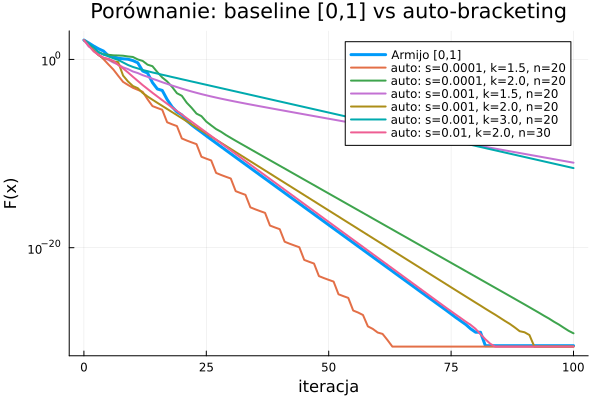

In [26]:
plot(title="Porównanie: baseline [0,1] vs auto-bracketing", xlabel="iteracja", ylabel="F(x)", yscale=:log10)

mean_fixed = mean(reduce(hcat, fixed_histories), dims=2)[:]
plot!(0:maxiter, mean_fixed; lw=3, label="Armijo [0,1]")

for p in bracket_params
    h = auto_histories_dict[(p.s, p.k, Float64(p.n))]
    m = mean(reduce(hcat, h), dims=2)[:]
    plot!(0:maxiter, m; lw=2, label="auto: s=$(p.s), k=$(p.k), n=$(p.n)")
end
current()


### Interpretacja części 5.0

Automatyczny bracketing z wykładu (`bracket_minimum`) usuwa stałe założenie `[0,1]` i dobiera przedział kroku lokalnie w każdej iteracji.

Dzięki temu skala kroku lepiej dopasowuje się do geometrii funkcji dla różnych punktów startowych.

W tym eksperymencie (`beta`, `c1` stałe) o jakości zbieżności decydują głównie parametry bracketingu: `s`, `k`, `n`.


## Wnioski końcowe

### 1. Stały krok
Stały krok jest najprostszy, ale wymaga strojenia. Na funkcji Himmelblaua bardzo dobrze widać, że:
- mały krok daje powolną poprawę,
- średni krok może działać bardzo dobrze,
- duży krok może prowadzić do niestabilności.

### 2. Armijo z bracketem `[0,1]`
To podejście jest bardziej odporne niż stały krok, bo każda iteracja dobiera krok adaptacyjnie.
Nie trzeba już aż tak zgadywać jednej dobrej wartości `α` dla całego procesu.

W części 4.0 zastosowano Armijo z początkowym bracketem \([0,1]\) poprzez ustawienie \(\alpha_0=1.0\) i backtracking.


### 3. Automatyczny bracketing
To jeszcze bardziej elastyczna wersja, bo nie zakładamy z góry tej samej skali kroku dla każdego punktu.
W praktyce często działa stabilniej, zwłaszcza gdy z różnych punktów startowych lokalna geometria funkcji jest różna.

### 4. Porównanie końcowe
W przeprowadzonych eksperymentach najlepsze wyniki dawały metody adaptacyjnego doboru kroku, 
ponieważ były mniej wrażliwe na wybór punktu startowego niż metoda ze stałym krokiem.
Stały krok może działać bardzo dobrze, ale wymaga wcześniejszego dostrojenia.
Warunek Armijo poprawia stabilność, a automatyczny bracketing dodatkowo lepiej dopasowuje skalę kroku do lokalnej geometrii funkcji.